In [1]:
from __future__ import print_function

%matplotlib inline

import numpy
import matplotlib.pyplot as plt

# Persamaan Nilai Batas: Diskretisasi

## Masalah Model

Masalah nilai batas (BVP) yang paling sederhana yang akan kita temui adalah versi satu dimensi dari persamaan Poisson:

$$
    u''(x) = f(x).
$$

Biasanya kita menyelesaikan persamaan ini pada suatu interval terbatas dengan kondisi batas Dirichlet atau Neumann. Karena persamaan ini memiliki turunan kedua, kita memerlukan dua kondisi batas agar persamaan diferensial parsial (dalam kasus ini sebenarnya persamaan diferensial biasa/ODE) dapat diselesaikan secara unik.
Sebagai permulaan, mari kita pertimbangkan masalah dasar berikut:

$$\begin{aligned}
    u''(x) = f(x) \quad \Omega = [a, b] \\
    u(a) = \alpha \quad u(b) = \beta.
\end{aligned}$$

BVP (masalah nilai batas) seperti ini sering kali muncul sebagai hasil dari memeriksa bentuk keadaan tunak dari persamaan diferensial parsial yang bergantung pada waktu. Misalnya, jika kita mempertimbangkan solusi steady-state dari persamaan panas:

$$
    u_t(x,t) = \kappa u_{xx}(x,t) + \Psi(x,t) \quad \Omega = [0, T] \times [a, b] \\
    u(x, 0) = u^0(x) \quad u(a, t) = \alpha(t) \quad u(b, t) = \beta(t)
$$

kita akan menyelesaikan persamaan dengan asumsi $u_t = 0$, sehingga diperoleh:

$$
u''(x) = - \frac{\Psi}{\kappa},
$$

yang merupakan versi dari persamaan Poisson seperti yang disebutkan sebelumnya.

Dalam dimensi ruang yang lebih tinggi, turunan kedua berubah menjadi Laplacian. Notasi untuk ini bervariasi, tetapi semua pernyataan berikut ekuivalen:

$$\begin{aligned}
    \nabla^2 u(\vec{x~}) &= f(\vec{x~}) \\
    \Delta u(\vec{x~}) &= f(\vec{x~}) \\
    \sum^N_{i=1} u_{x_i x_i} &= f(\vec{x~}).
\end{aligned}$$

## Diskretisasi Satu Dimensi

Sebagai pendekatan awal untuk menyelesaikan persamaan Poisson satu dimensi, mari kita bagi domain menjadi `m` titik, yang sering disebut sebagai mesh atau grid. Tujuan kita adalah untuk mendekati fungsi tak diketahui $u(x)$ pada titik-titik mesh $x_i$.

Pertama, kita bisa menghubungkan jumlah titik mesh `m` dengan jarak antar titik melalui:

$$
\Delta x = \frac{1}{m + 1}.
$$

Titik-titik mesh $x_i$ dapat dituliskan sebagai:

$$
x_i = a + i \Delta x.
$$

Kita bisa membiarkan $\Delta x$ bervariasi, dan banyak rumus di atas hanya membutuhkan sedikit modifikasi, tetapi itu akan kita tinggalkan sebagai pekerjaan rumah.

Secara notasi, kita juga akan menggunakan:

$$
U_i \approx u(x_i)
$$

artinya $U_i$ adalah perkiraan solusi pada titik-titik grid, sementara huruf kecil $u$ tetap digunakan untuk menyatakan solusi sebenarnya.

Untuk menyederhanakan pembahasan, mari kita pertimbangkan persamaan diferensial biasa (ODE) berikut:

$$
    u''(x) = f(x) \quad \Omega = [0, 1] \\
    u(0) = \alpha \quad u(1) = \beta.
$$
Di sini:

* $\Omega = [0,1]$ adalah interval tempat kita mencari solusi.
* $u(0) = \alpha$ dan $u(1) = \beta$ adalah kondisi batas Dirichlet di ujung interval.

Dengan menerapkan aproksimasi beda hingga pusat orde kedua untuk turunan kedua, kita memperoleh persamaan:

$$
D^2 U_i = \frac{1}{\Delta x^2} (U_{i+1} - 2 U_i + U_{i-1}),
$$

sehingga kita mendapatkan persamaan aljabar perkiraan pada setiap titik grid:

$$
\frac{1}{\Delta x^2} (U_{i+1} - 2 U_i + U_{i-1}) = f(x_i), \quad i = 1, 2, 3, \ldots, m.
$$

Perlu dicatat bahwa pada titik ini, persamaan aljabar tersebut **terkait satu sama lain** karena setiap $U_i$ bergantung pada nilai tetangganya.

Ini berarti kita bisa menuliskannya sebagai sistem persamaan yang terhubung:

$$
A U = F.
$$

#### Menuliskan sistem persamaan

Sistem persamaan aljabar dari:

$$
\frac{1}{\Delta x^2} (U_{i+1} - 2 U_i + U_{i-1}) = f(x_i), \quad i = 1, 2, 3, \ldots, m
$$

dengan memperhatikan kondisi batas $U_0 = \alpha$ dan $U_{m+1} = \beta$, dapat ditulis sebagai:

$$
\begin{aligned}
\frac{1}{\Delta x^2} (U_2 - 2 U_1 + \alpha) &= f(x_1) \
\frac{1}{\Delta x^2} (U_3 - 2 U_2 + U_1) &= f(x_2) \
\frac{1}{\Delta x^2} (U_4 - 2 U_3 + U_2) &= f(x_3) \
&;;\vdots \
\frac{1}{\Delta x^2} (\beta - 2 U_m + U_{m-1}) &= f(x_m)
\end{aligned}
$$


$$
    \frac{1}{\Delta x^2} \begin{bmatrix}
    -2 &  1 &    &    &    \\
     1 & -2 &  1 &    &    \\
       &  1 & -2 &  1 &    \\
       &    &  1 & -2 &  1 \\
       &    &    &  1 & -2 \\
    \end{bmatrix} \begin{bmatrix}
        U_1 \\ U_2 \\ U_3 \\ U_4 \\ U_5
    \end{bmatrix} = 
    \begin{bmatrix}
        f(x_1) - \frac{\alpha}{\Delta x^2} \\ f(x_2) \\ f(x_3) \\ f(x_4) \\ f(x_5) - \frac{\beta}{\Delta x^2} \\
    \end{bmatrix}.
$$

#### Contoh

Kita ingin menyelesaikan BVP:

$$
u_{xx} = e^x, \quad x \in [0, 1], \quad \text{dengan} \quad u(0) = 0 \text{ dan } u(1) = 3
$$

melalui pembuatan sistem persamaan linear menggunakan pendekatan beda hingga.

$$\begin{aligned}
    u_{xx} &= e^x \\
    u_x &= A + e^x \\
    u &= Ax + B + e^x\\
    u(0) &= B + 1 = 0 \Rightarrow B = -1 \\
    u(1) &= A - 1 + e^{1} = 3 \Rightarrow A = 4 - e\\ 
    ~\\
    u(x) &= (4 - e) x - 1 + e^x
\end{aligned}$$

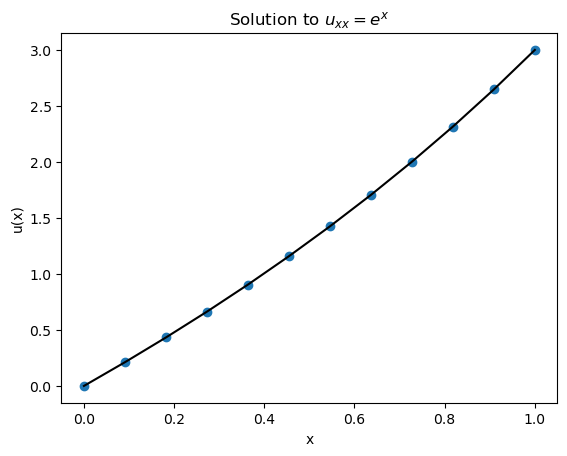

In [2]:
# Problem setup
a = 0.0
b = 1.0
u_a = 0.0
u_b = 3.0
f = lambda x: numpy.exp(x)
u_true = lambda x: (4.0 - numpy.exp(1.0)) * x - 1.0 + numpy.exp(x)

# Descretization
m = 10
x_bc = numpy.linspace(a, b, m + 2)
x = x_bc[1:-1]
delta_x = (b - a) / (m + 1)

# Construct matrix A
A = numpy.zeros((m, m))
diagonal = numpy.ones(m) / delta_x**2
A += numpy.diag(diagonal * -2.0, 0)
A += numpy.diag(diagonal[:-1], 1)
A += numpy.diag(diagonal[:-1], -1)

# Construct RHS
b = f(x)
b[0] -= u_a / delta_x**2
b[-1] -= u_b / delta_x**2

# Solve system
U = numpy.empty(m + 2)
U[0] = u_a
U[-1] = u_b
U[1:-1] = numpy.linalg.solve(A, b)

# Plot result
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(x_bc, U, 'o', label="Computed")
axes.plot(x_bc, u_true(x_bc), 'k', label="True")
axes.set_title("Solution to $u_{xx} = e^x$")
axes.set_xlabel("x")
axes.set_ylabel("u(x)")
plt.show()

## Analisis Galat

Pertanyaan yang wajar untuk diajukan terkait aproksimasi $U_i$ kita adalah seberapa dekat nilai ini dengan solusi sebenarnya $u(x)$ pada titik-titik grid $x_i$.

Untuk menanganinya, kita definisikan galat $E$ sebagai:

$$
E = U - \widehat{U},
$$

di mana $U$ adalah vektor solusi perkiraan, dan $\widehat{U}$ adalah vektor yang terdiri dari nilai-nilai $u(x_i)$ sehingga:

$$
\widehat{U_i} = u(x_i).
$$

Dengan demikian, $E$ memberi ukuran seberapa jauh aproksimasi $U_i$ menyimpang dari solusi sebenarnya di setiap titik grid.

Ini membuat $E$ tetap menjadi sebuah vektor, sehingga sering kali kita menanyakan bagaimana norma dari $E$ berubah untuk nilai tertentu $\Delta x$.
Untuk norma tak hingga ($\infty$-norm), kita memiliki:

$$
    ||E||_\infty = \max_{1 \leq i \leq m} |E_i| = \max_{1 \leq i \leq m} |U_i - u(x_i)|
$$


Jika kita dapat menunjukkan bahwa $||E||_\infty$ mendekati nol saat $\Delta x \rightarrow 0$, maka kita dapat menyimpulkan bahwa solusi perkiraan $U_i$ pada setiap titik grid mendekati solusi sebenarnya, yaitu $E_i \rightarrow 0$.
Jika kita ingin menggunakan norma lain, sering kali kita mendefinisikan versi yang sedikit dimodifikasi dari norma tersebut yang juga memasukkan lebar grid $\Delta x$, yaitu:

$$\begin{aligned}
    ||E||_1 &= \Delta x \sum^m_{i=1} |E_i| \\
    ||E||_2 &= \left( \Delta x \sum^m_{i=1} |E_i|^2 \right )^{1/2}
\end{aligned}$$

Norma-norma ini disebut norma fungsi grid (grid function norms).

Galat $E$ yang didefinisikan di atas dikenal sebagai galat global (global error). Salah satu tujuan utama dalam mata kuliah ini adalah memahami perilaku $E$ terkait faktor-faktor lain yang akan kita definisikan kemudian.


### Galat Truncasi Lokal

Galat truncasi lokal dapat didefinisikan dengan menggantikan solusi perkiraan $U_i$ oleh solusi sebenarnya $u(x_i)$.
Karena persamaan aljabar adalah aproksimasi dari BVP asli, kita tidak mengharapkan solusi sebenarnya akan memenuhi persamaan ini secara tepat. Perbedaan yang muncul akibat hal ini inilah yang disebut LTE.

Untuk aproksimasi beda hingga satu dimensi yang telah kita bahas di atas, kita memiliki persamaan:

$$
\frac{1}{\Delta x^2} (U_{i+1} - 2 U_i + U_{i-1}) = f(x_i).
$$

Menggantikan $U_i$ dengan solusi sebenarnya $u(x_i)$ dalam persamaan ini menghasilkan:

$$
\tau_i = \frac{1}{\Delta x^2} \big(u(x_{i+1}) - 2 u(x_i) + u(x_{i-1})\big) - f(x_i).
$$

Dalam bentuk ini, LTE belum terlalu berguna. Namun, jika kita mengasumsikan bahwa $u(x)$ halus, kita bisa mengganti $u(x_i)$ dengan deret Taylor-nya, mirip seperti yang kita lakukan pada beda hingga.

Deret Taylor yang relevan adalah:

$$
u(x_{i \pm 1}) = u(x_i) \pm u'(x_i) \Delta x + \frac{1}{2} u''(x_i) \Delta x^2 \pm \frac{1}{6} u'''(x_i) \Delta x^3 + \frac{1}{24} u^{(4)}(x_i) \Delta x^4 + \mathcal{O}(\Delta x^5)
$$

Ini menghasilkan ekspresi untuk galat truncasi lokal $\tau_i$ sebagai berikut:

$$\begin{aligned}
\tau_i &= \frac{1}{\Delta x^2} \left [u''(x_i) \Delta x^2 + \frac{1}{12} u^{(4)}(x_i) \Delta x^4 + \mathcal{O}(\Delta x^5) \right ] - f(x_i) \
&= u''(x_i) + \frac{1}{12} u^{(4)}(x_i) \Delta x^2 + \mathcal{O}(\Delta x^4) - f(x_i) \
&= \frac{1}{12} u^{(4)}(x_i) \Delta x^2 + \mathcal{O}(\Delta x^4)
\end{aligned}$$

Di sini kita mencatat bahwa solusi sebenarnya memenuhi $u''(x) = f(x)$, sehingga term utama dari persamaan di atas tersisa hanya dari turunan keempat.

Selama $u^{(4)}(x_i)$ tetap terbatas (smooth), kita tahu bahwa:
$
\tau_i \rightarrow 0 \quad \text{seiring} \quad \Delta x \rightarrow 0.
$

Kita juga bisa menuliskan vektor galat truncasi lokal (LTE) sebagai:

$$
\tau = A \widehat{U} - F,
$$

yang implikasinya adalah:

$$
A\widehat{U} = F + \tau.
$$

Perlu dicatat bahwa di sini $\widehat{U}$ adalah solusi sebenarnya yang dievaluasi pada stencil, bukan fungsi perkiraan.

Artinya, persamaan aljabar yang kita bentuk dari beda hingga tidak dipenuhi secara tepat oleh solusi asli, dan perbedaan itulah yang direpresentasikan oleh $\tau$.


### Galat Global

Yang sebenarnya ingin kita batasi adalah galat global $E$. Untuk menghubungkan galat global dengan LTE, kita bisa mengganti $E = U - \widehat{U}$ ke dalam ekspresi LTE dan diperoleh:

$$
A E = -\tau.
$$

Artinya, galat global adalah solusi dari sistem persamaan aljabar yang sama dengan yang kita gunakan untuk aproksimasi $U$, etapi dengan $\tau$ sebagai fungsi sumber alih-alih $F$.
Dengan kata lain, perilaku galat global ditentukan oleh magnitudo dan distribusi LTE melalui sistem matriks $A$.

Ini juga menyiratkan bahwa galat global $E$ dapat dianggap sebagai solusi aproksimasi dari BVP serupa dengan persamaan:
$$
    e''(x) = -\tau(x) \quad \Omega = [0, 1] \\
    e(0) = 0 \quad e(1) = 0.
$$

Kita bisa menyelesaikan ODE ini secara langsung dengan mengintegrasikan dua kali, sehingga diperoleh, hingga orde utama:

$$\begin{aligned}
    e(x) &\approx -\frac{1}{12} \Delta x^2 u''(x) + \frac{1}{12} \Delta x^2 (u''(0) + x (u''(1) - u''(0))) \\
    &= \mathcal{O}(\Delta x^2) \rightarrow 0 \quad \text{as} \quad \Delta x \rightarrow 0.
\end{aligned}$$


### Stabilitas

Kita telah menunjukkan bahwa analogi kontinu dari $E$, yaitu $e(x)$, memang mendekati nol saat $\Delta x \rightarrow 0$. Namun, bagaimana dengan vektor galat global $E$ pada grid diskret?
Alih-alih menggunakan argumen dari $e(x)$, mari kita lihat kembali sistem persamaan asli untuk galat global:

$$
A_{\Delta x} E_{\Delta x} = - \tau_{\Delta x},
$$

di mana kita sekarang menandai realiasi tertentu dari sistem dengan jarak grid $\Delta x$.

Jika kita bisa membalikkan $A_{\Delta x}$, kita dapat menghitung $E_{\Delta x}$ secara langsung. Dengan asumsi kita bisa melakukannya, dan menggunakan norma yang sesuai, diperoleh:
$$\begin{aligned}
    E_{\Delta x} &= (A_{\Delta x})^{-1} \tau_{\Delta x} \\
    ||E_{\Delta x}|| &= ||(A_{\Delta x})^{-1} \tau_{\Delta x}|| \\
    & \leq ||(A_{\Delta x})^{-1} ||~|| \tau_{\Delta x}||
\end{aligned}$$

Kita sudah mengetahui bahwa $\tau_{\Delta x} \rightarrow 0$ saat $\Delta x \rightarrow 0$ pada contoh kita. Jika kita juga bisa membatasi norma matriks invers $(A_{\Delta x})^{-1}$ dengan suatu konstanta $C$ untuk $\Delta x$ yang cukup kecil, maka kita dapat menuliskan batasan untuk galat global sebagai:

$$
||E_{\Delta x}|| \leq C , ||\tau_{\Delta x}||.
$$

Kita dapat menggeneralisasi pengamatan ini untuk semua masalah BVP linear dengan menganggap bahwa kita memiliki aproksimasi beda hingga untuk BVP linear dalam bentuk:

$$
A_{\Delta x} U_{\Delta x} = F_{\Delta x},
$$

di mana $\Delta x$ adalah jarak grid.

Kita mengatakan bahwa aproksimasi tersebut stabil jika $(A_{\Delta x})^{-1}$ ada untuk semua $\Delta x < \Delta x_0$ dan terdapat suatu konstanta $C$ sehingga:

$$
||(A_{\Delta x})^{-1}|| \leq C \quad \forall \Delta x < \Delta x_0.
$$


### Konsistensi

Ide yang terkait dan penting dalam diskretisasi PDE adalah agar aproksimasi tersebut konsisten dengan persamaan diferensial yang kita aproksimasi.

Jika:

$$
||\tau_{\Delta x}|| \rightarrow 0 \quad \text{seiring} \quad \Delta x \rightarrow 0,
$$

maka kita mengatakan aproksimasi tersebut konsisten dengan persamaan diferensial.

### Konvergensi

Sekarang kita memiliki semua komponen untuk membahas galat global $E$.
Sebuah metode dikatakan konvergen jika:

$$
||E_{\Delta x}|| \rightarrow 0 \quad \text{seiring} \quad \Delta x \rightarrow 0.
$$

Jika suatu aproksimasi konsisten
($||\tau_{\Delta x}|| \rightarrow 0$ saat $\Delta x \rightarrow 0$)
dan **stabil**
($||E_{\Delta x}|| \leq C , ||\tau_{\Delta x}||$),
maka aproksimasi tersebut konvergen.

Kita baru saja menurunkan hal ini untuk **BVP linear**, tetapi kenyataannya **kriteria konvergensi ini sering berlaku** untuk hampir semua aproksimasi beda hingga (dan bahkan metode numerik lainnya).
Pernyataan konvergensi ini juga sering dapat diperkuat menjadi:

$$
\mathcal{O}(\Delta x^p) \text{ LTE } + \text{stabilitas} ;; \Rightarrow ;; \mathcal{O}(\Delta x^p) \text{ galat global}.
$$

Ternyata, bagian yang paling sulit dari proses ini biasanya adalah **menunjukkan stabilitas**.
Pada bagian berikutnya, kita akan melihat **untuk contoh sederhana kita** bagaimana kita dapat membuktikan **stabilitas dalam norma 2** ($2$-norm).



### Stabilitas dalam 2-Norma

Mengacu pada definisi stabilitas, kita perlu menunjukkan bahwa untuk matriks $A$ yang telah kita definisikan sebelumnya:

1. Matriks invers **ada**:
   $$
   (A_{\Delta x})^{-1} \text{ ada},
   $$

2. Dan norma 2 dari inversnya **terbatas** oleh suatu konstanta $C$ untuk semua $\Delta x < \Delta x_0$:
   $$
   ||(A_{\Delta x})^{-1}||_2 \leq C, \quad \forall \Delta x < \Delta x_0.
   $$

Jika ini terpenuhi, maka aproksimasi **stabil dalam norma 2**, artinya galat global tidak akan membesar akibat sistem diskret saat grid diperhalus.

Sekarang kita bisa berasumsi bahwa $A$ memang **dapat dibalik (invertible)**, tetapi pertanyaannya adalah: **bisakah kita membatasi norma inversnya?**
Ingat bahwa **2-norma** dari matriks simetris sama dengan **radius spektralnya** (spectral radius):

$$
    ||A||_2 = \rho(A) = \max_{1\leq p \leq m} |\lambda_p|.
$$

di mana $\lambda_p$ adalah **nilai eigen** dari $A$.

Dengan kata lain, untuk matriks simetris, **norma 2 dari invers** dapat dinyatakan sebagai:

$$
||A^{-1}||_2 = \frac{1}{\min_p |\lambda_p|}.
$$

Karena invers dari $A$ juga simetris, **nilai eigen dari $A^{-1}$ adalah invers dari nilai eigen $A$**, sehingga:

$$
||A^{-1}||*2 = \rho(A^{-1}) = \max*{1 \leq p \leq m} \left| \frac{1}{\lambda_p} \right|.
$$

Perlu diperhatikan, untuk matriks positif-definit simetris seperti matriks beda hingga kita:

$$
||A^{-1}||*2 = \frac{1}{\min*{1 \leq p \leq m} |\lambda_p|}.
$$

Jika tidak ada $\lambda_p$ dari $A$ yang bernilai nol untuk $\Delta x$ yang cukup kecil, dan nilai-nilai eigen lainnya tetap terbatas saat $\Delta x \rightarrow 0$, maka kita telah **menunjukkan stabilitas aproksimasi** tersebut.

Nilai eigen dari matriks $A$ yang dibahas di atas dapat dituliskan sebagai

$$
\lambda_p = \frac{2}{\Delta x^2} (\cos(p \pi \Delta x) - 1),
$$

dengan **vektor eigen** yang sesuai $v^p$:

$$
v^p_j = \sin(p \pi j \Delta x),
$$

di mana $v^p_j$ adalah komponen ke-$j$ dengan $j = 1, \ldots, m$.



#### Periksa bahwa ini memang pasangan eigen dari matriks $A$

$$
\lambda_p = \frac{2}{\Delta x^2} (\cos(p \pi \Delta x) - 1)
$$

$$
v^p_j = \sin(p \pi j \Delta x)
$$

$$\begin{aligned}
    (A v^p)_j &= \frac{1}{\Delta x^2} (v^p_{j-1} - 2 v^p_j + v^p_{j+1} ) \\
    &= \frac{1}{\Delta x^2} (\sin(p \pi (j-1) \Delta x) - 2 \sin(p \pi j \Delta x) + \sin(p \pi (j+1) \Delta x) ) \\
    &= \frac{1}{\Delta x^2} (\sin(p \pi j \Delta x) \cos(p \pi \Delta x) - 2 \sin(p \pi j \Delta x) + \sin(p \pi j \Delta x) \cos(p \pi \Delta x) \\
    &= \lambda_p v^p_j.
\end{aligned}$$

#### Hitung nilai eigen terkecil

Jika kita bisa menunjukkan bahwa **nilai-nilai eigen berada jauh dari nol**, maka kita tahu bahwa $||A||_2$ akan **terbatas**. Dalam kasus ini, nilai-nilai eigen **negatif**, sehingga kita perlu menunjukkan bahwa mereka **selalu lebih kecil dari nol**.

$$
\lambda_p = \frac{2}{\Delta x^2} (\cos(p \pi \Delta x) - 1)
$$

Gunakan **deret Taylor** untuk mendapatkan gambaran bagaimana $\lambda_p$ **berperilaku terhadap $\Delta x$**.


Dari ekspresi-ekspresi ini kita mengetahui bahwa **nilai eigen terkecil** adalah:
$$\begin{aligned}
    \lambda_1 &= \frac{2}{\Delta x^2} (\cos(p \pi \Delta x) - 1) \\
    &= \frac{2}{\Delta x^2} \left (-\frac{1}{2} p^2 \pi^2 \Delta x^2 + \frac{1}{24} p^4 \pi^4 \Delta x^4 + \mathcal{O}(\Delta^6) \right ) \\
    &= -p^2 \pi^2 + \mathcal{O}(\Delta x^2).
\end{aligned}$$

Perlu dicatat bahwa ini juga memberikan **batas galat**, karena nilai eigen ini akan menentukan **nilai eigen terbesar dari matriks invers**. Oleh karena itu, kita dapat menulis:
$$
    ||E^{\Delta x}||_2 \leq ||(A^{\Delta x})^{-1}||_2 ||\tau^{\Delta x}||_2 \approx \frac{1}{\pi^2} ||\tau^{\Delta x}||_2.
$$

### Stabilitas dalam Norma Tak Hingga ($\infty$-Norm)

Pendekatan langsung untuk menunjukkan bahwa $||E||_\infty \rightarrow 0$ saat $\Delta x \rightarrow 0$ adalah dengan menggunakan **batas matriks**:
$$
||E||_\infty \leq \frac{1}{\sqrt{\Delta x}} , ||E||_2.
$$

Untuk masalah contoh kita, kita telah menunjukkan bahwa $||E||_2 = \mathcal{O}(\Delta x^2)$, sehingga ini menyiratkan bahwa setidaknya kita tahu: $||E||_\infty = \mathcal{O}(\Delta x^{3/2}).$
Hal ini kurang ideal karena kita **mengharapkan** $||E||_\infty = \mathcal{O}(\Delta x^2)$ akibat diskretisasi.
Untuk mengatasi masalah ini, mari kita kembali dan mempertimbangkan **definisi stabilitas**, tetapi kali ini menggunakan **norma $\infty$**.

Matriks $A$ kita dapat dilihat sebagai sejumlah **aproksimasi diskret terhadap fungsi Green** pada setiap kolomnya.
Hal ini memiliki **aplikasi yang lebih luas** di kemudian hari, sehingga kita akan meluangkan waktu untuk **meninjau teori fungsi Green** dan menerapkannya pada **masalah contoh sederhana kita**.


### Fungsi Green

Pertimbangkan **BVP** dengan kondisi batas Dirichlet:

$$
    u''(x) = f(x) \quad \Omega = [0, 1] \\
    u(0) = \alpha \quad u(1) = \beta.
$$

Pilih titik tetap $\bar{x} \in \Omega$. **Fungsi Green** $G(x;\bar{x})$ menyelesaikan BVP di atas dengan:

$$
    f(x) = \delta(x - \bar{x})
$$

Anda dapat memikirkan ini sebagai hasil dari **masalah keadaan tunak (steady-state)** pada persamaan panas dengan **kehilangan panas pada satu titik** di dalam domain.

Untuk menemukan **fungsi Green** untuk masalah kita, kita bisa melakukan integrasi **di sekitar titik** $\bar{x}$ yang berdekatan dengan sumber fungsi $\delta$:

$$\begin{aligned}
    \int^{\bar{x} + \epsilon}_{\bar{x} - \epsilon} u''(x) dx &= \int^{\bar{x} + \epsilon}_{\bar{x} - \epsilon} \delta(x - \bar{x}) dx \\
    u'(\bar{x} + \epsilon) - u'(\bar{x} - \epsilon) &= 1
\end{aligned}$$

Ingat bahwa **definisi integral dari fungsi $\delta$** adalah 1 jika interval integrasi mencakup $\bar{x}$.
Dari sini kita melihat bahwa **terjadi loncatan (jump) pada turunan $u'$** di titik $\bar{x}$ sebesar 1, dari kiri ke kanan.

Setelah sedikit aljabar, kita dapat menyelesaikan **fungsi Green** untuk BVP model kita sebagai:

$$
    G(x; \bar{x}) = \left \{ \begin{aligned}
        (\bar{x} - 1) x & & 0 \leq x \leq \bar{x} \\
        \bar{x} (x - 1) & & \bar{x} \leq x \leq 1
    \end{aligned} \right . .
$$

Salah satu **sifat penting** dari PDE (atau ODE) linear secara umum adalah bahwa mereka mematuhi **prinsip superposisi**.
Alasan kita memperhatikan hal ini dalam konteks **fungsi Green** adalah: jika kita memiliki $f(x)$ yang terdiri dari dua fungsi $\delta$, maka solusi dari BVP adalah **jumlah dari kedua fungsi Green yang bersesuaian**.

Sebagai contoh, jika:

$$
f(x) = \delta(x - 0.25) + 2 , \delta(x - 0.5),
$$

maka solusinya adalah:

$$
u(x) = G(x; 0.25) + 2 , G(x; 0.5).
$$

Tentu saja, hal ini dapat diperluas ke **jumlah tak hingga fungsi $\delta$**, sehingga:

$$
f(x) = \int_0^1 f(\bar{x}) , \delta(x - \bar{x}) , d\bar{x},
$$

dan oleh karena itu:

$$
u(x) = \int_0^1 f(\bar{x}) , G(x; \bar{x}) , d\bar{x}.
$$

Untuk memasukkan **efek dari kondisi batas**, kita dapat terus menambahkan **fungsi Green** ke solusi sehingga diperoleh **solusi umum** dari BVP asli kita sebagai:

$$
u(x) = \alpha (1 - x) + \beta x + \int_0^1 f(\bar{x}) , G(x; \bar{x}) , d\bar{x}.
$$

Jadi, mengapa kita melakukan semua ini?
Solusi **fungsi Green** di atas dapat dianggap sebagai **operator linear** pada fungsi $f(x)$. Ditulis dalam istilah yang mungkin lebih familiar:

$$
\mathcal{A} u = f \quad \Rightarrow \quad u = \mathcal{A}^{-1} f.
$$

Sekarang kita melihat bahwa **operator linear** $\mathcal{A}$ ini dapat dianggap sebagai **analogi kontinu** dari matriks diskret $A$ yang kita gunakan sebelumnya.

Untuk melanjutkan, kita akan memodifikasi **matriks $A$ asli** menjadi versi yang sedikit berbeda berdasarkan diskretisasi yang sama.
Alih-alih memindahkan **nilai-nilai batas** ke sisi kanan persamaan, kita akan memperkenalkan dua **“sel hantu” (ghost cells)** baru yang ditempatkan di tepi grid. Kita akan memberi label **$U_0$** dan **$U_{m+1}$**.
Sebenarnya, kita **sudah mengetahui nilai** dari titik-titik ini, karena mereka adalah **kondisi batas**!

Sistem yang telah dimodifikasi kemudian terlihat seperti:

$$
    A = \frac{1}{\Delta x^2} \begin{bmatrix}
        \Delta x^2 & 0  \\
        1 & -2 & 1 \\
          &  1 & -2 & 1 \\
          &    & \ddots & \ddots & \ddots \\
          &    &        &      1 &     -2 & 1 \\
          &    &        &        &      1 & -2 & 1 \\
          &    &        &        &        &  0 & \Delta x^2
    \end{bmatrix} \quad \quad U = \begin{bmatrix}
        U_0 \\ U_1 \\ \vdots \\ U_m \\ U_{m+1}
    \end{bmatrix} \quad \quad F = \begin{bmatrix}
        \alpha \\ f(x_1) \\ \vdots \\ f(x_{m}) \\ \beta
    \end{bmatrix}  
$$

Keuntungan dari pendekatan ini adalah:

* Kita dapat **mengimplementasikan kondisi batas yang lebih umum** di kemudian hari,
* Dependensi aljabar terhadap kondisi batas menjadi **terisolasi**.

Kekurangannya adalah :
* Matriks **tidak lagi sesederhana** bentuk sebelumnya.

Akhirnya, mari kita lihat **bentuk matriks $A^{-1}$**. Dengan memperkenalkan sedikit notasi tambahan, biarkan $A_j$ menyatakan **kolom ke-$j$** dan $A_{ij}$ menyatakan **elemen baris ke-$i$, kolom ke-$j$** dari matriks $A$.

Kita tahu bahwa:

$$
A , A^{-1}_j = e_j,
$$

di mana $e_j$ adalah **vektor satuan** dengan nilai $1$ pada baris ke-$j$ (kolom ke-$j$ dari matriks identitas).

Perhatikan bahwa sistem di atas memiliki beberapa kemiripan dengan versi diskret dari masalah fungsi Green.

Di sini:

* $e_j$ **mewakili fungsi $\delta$**,
* $A$ adalah **operator asli**,
* $A^{-1}_j$ adalah **pengaruh dari fungsi $\delta$ ke-$j$** (sesuai dengan $\bar{x}$) terhadap **solusi penuh**.

Ternyata kita dapat menuliskan **matriks invers secara langsung** menggunakan **fungsi Green** (lihat LeVeque untuk detailnya), dan kita memperoleh:
$$
    A^{-1}_{ij} = \Delta xG(x_i ; x_j) = \left \{ \begin{aligned}
        \Delta x (x_j - 1) x_i, & & i &= 1,2, \ldots j \\
        \Delta x (x_i - 1) x_j, & & i &= j, j+1, \ldots , m
    \end{aligned} \right . .
$$

Kita juga dapat menuliskan **sisi kanan efektif** dari sistem kita sebagai:

$$
F = \alpha , e_0 + \beta , e_{m+1} + \sum_{j=1}^m f_j , e_j,
$$

dan akhirnya **solusinya** adalah:

$$
U = \alpha , A^{-1}*{0} + \beta , A^{-1}*{m+1} + \sum_{j=1}^m f_j , A^{-1}_{j},
$$

dengan elemen-elemen:

$$
U_i = \alpha (1 - x_i) + \beta x_i + \Delta x \sum_{j=1}^m f_j , G(x_i; x_j).
$$

Baiklah, ke mana semua ini membawa kita? Karena sekarang kita **mengetahui bentuk $A^{-1}$**, kita mungkin dapat menghitung **$\infty$-norm** dari matriks ini.
Ingat bahwa **$\infty$-norm dari sebuah matriks** (diinduksi dari $\infty$-norm pada vektor) didefinisikan sebagai:

$$
    || C ||_\infty = \max_{0\leq i \leq m+1} \sum^{m+1}_{j=0} |C_{ij}|
$$

Perlu dicatat bahwa **karena bentuk matriks $A^{-1}$**, jumlah elemen pada baris pertama adalah:

$$
\sum_{j=0}^{m+1} A_{0j}^{-1} = 1,
$$

demikian juga untuk baris terakhir $A^{-1}_{m+1}$. Kita juga tahu bahwa untuk baris-barisan lainnya: $A^{-1}_{i,0} < 1$ dan $A^{-1}_{i,m+1} < 1$.

Baris-barisan **di tengah** juga semuanya **terbatas** sebagai:

$$
\sum_{j=0}^{m+1} |A^{-1}_{ij}| \leq 1 + 1 + m \Delta x < 3,
$$

dengan menggunakan fakta bahwa:

$$
\Delta x = \frac{1}{m+1}.
$$

Ini menyelesaikan pembahasan kita tentang **stabilitas**, karena sekarang kita dapat mengatakan dengan tegas bahwa:

$$
||A^{-1}||_\infty < 3 \quad \forall \Delta x.
$$


## Kondisi Batas Neumann

Seperti yang telah disebutkan sebelumnya, kita dapat **memasukkan jenis kondisi batas lain** ke dalam diskretisasi kita menggunakan versi **modifikasi dari matriks**.

Mari kita coba lakukan ini untuk masalah asli kita, tetapi dengan **satu sisi menggunakan kondisi batas Neumann**:

$$
    u''(x) = f(x) \quad \Omega = [-1, 1] \\
    u(-1) = \alpha \quad u'(1) = \sigma.
$$

**Latihan**

$$
    u''(x) = f(x) \quad \Omega = [-1, 1] \\
    u(-1) = \alpha \quad u'(1) = \sigma.
$$

$$
    u(x) = -(5 + e) x - (2 + e + e^{-1}) + e^x
$$

Eksplorasi **implementasi kondisi batas Neumann** dengan cara:

1. menggunakan **ekspresi satu sisi (one-sided) orde pertama**,
2. menggunakan **ekspresi terpusat (centered) orde kedua**, dan
3. menggunakan **ekspresi satu sisi (one-sided) orde kedua**.


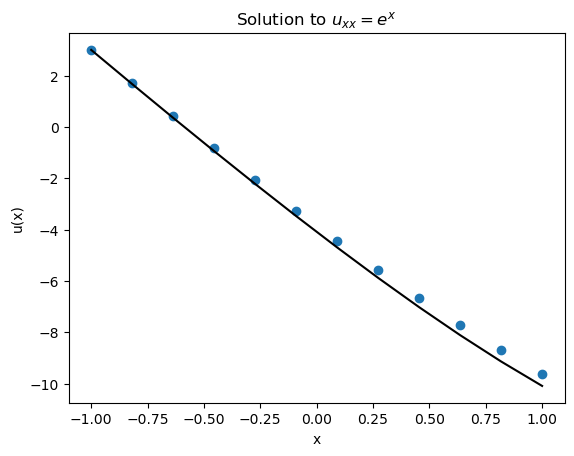

In [3]:
def solve_mixed_1st_order_one_sided(m):
    # Problem setup
    a = -1.0
    b = 1.0
    alpha = 3.0
    sigma = -5.0
    f = lambda x: numpy.exp(x)

    # Descretization
    x_bc = numpy.linspace(a, b, m + 2)
    x = x_bc[1:-1]
    delta_x = (b - a) / (m + 1)

    # Construct matrix A
    A = numpy.zeros((m + 2, m + 2))
    diagonal = numpy.ones(m + 2) / delta_x**2
    A += numpy.diag(diagonal * -2.0, 0)
    A += numpy.diag(diagonal[:-1], 1)
    A += numpy.diag(diagonal[:-1], -1)

    # Construct RHS
    b = f(x_bc)

    # Boundary conditions
    A[0, 0] = 1.0
    A[0, 1] = 0.0
    A[-1, -1] = 1.0 / (delta_x)
    A[-1, -2] = -1.0 / (delta_x)

    b[0] = alpha
    b[-1] = sigma

    # Solve system
    U = numpy.linalg.solve(A, b)

    return x_bc, U


u_true = lambda x: -(5.0 + numpy.exp(1.0)) * x - (2.0 + numpy.exp(1.0) + numpy.exp(-1.0)) + numpy.exp(x)

x_bc, U = solve_mixed_1st_order_one_sided(10)
    
# Plot result
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(x_bc, U, 'o', label="Computed")
axes.plot(x_bc, u_true(x_bc), 'k', label="True")
axes.set_title("Solution to $u_{xx} = e^x$")
axes.set_xlabel("x")
axes.set_ylabel("u(x)")
plt.show()

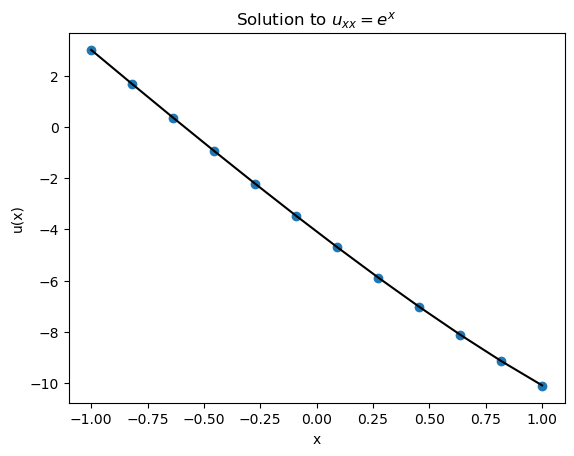

In [4]:
def solve_mixed_2nd_order_centered(m):
    # Problem setup
    a = -1.0
    b = 1.0
    alpha = 3.0
    sigma = -5.0
    f = lambda x: numpy.exp(x)

    # Descretization
    x_bc = numpy.linspace(a, b, m + 2)
    x = x_bc[1:-1]
    delta_x = (b - a) / (m + 1)

    # Construct matrix A
    A = numpy.zeros((m + 2, m + 2))
    diagonal = numpy.ones(m + 2) / delta_x**2
    A += numpy.diag(diagonal * -2.0, 0)
    A += numpy.diag(diagonal[:-1], 1)
    A += numpy.diag(diagonal[:-1], -1)

    # Construct RHS
    b = f(x_bc)

    # Boundary conditions
    A[0, 0] = 1.0
    A[0, 1] = 0.0
    A[-1, -1] = -1.0 / (delta_x)
    A[-1, -2] =  1.0 / (delta_x)

    b[0] = alpha
    b[-1] = delta_x / 2.0 * f(x_bc[-1]) - sigma

    # Solve system
    U = numpy.linalg.solve(A, b)

    return x_bc, U

x_bc, U = solve_mixed_2nd_order_centered(10)
    
# Plot result
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(x_bc, U, 'o', label="Computed")
axes.plot(x_bc, u_true(x_bc), 'k', label="True")
axes.set_title("Solution to $u_{xx} = e^x$")
axes.set_xlabel("x")
axes.set_ylabel("u(x)")
plt.show()

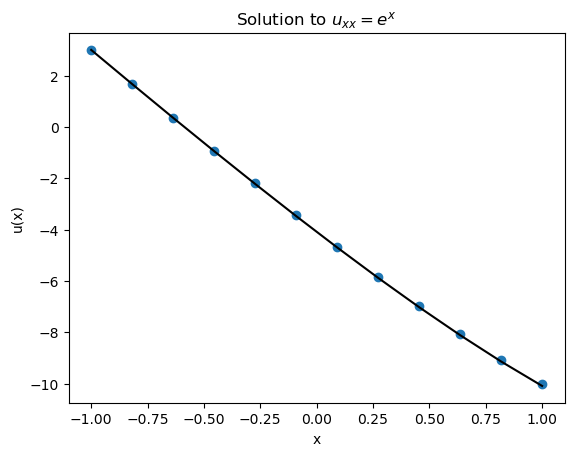

In [5]:
def solve_mixed_2nd_order_one_sided(m):
    # Problem setup
    a = -1.0
    b = 1.0
    alpha = 3.0
    sigma = -5.0
    f = lambda x: numpy.exp(x)
    
    # Descretization
    x_bc = numpy.linspace(a, b, m + 2)
    x = x_bc[1:-1]
    delta_x = (b - a) / (m + 1)
    
    # Construct matrix A
    A = numpy.zeros((m + 2, m + 2))
    diagonal = numpy.ones(m + 2) / delta_x**2
    A += numpy.diag(diagonal * -2.0, 0)
    A += numpy.diag(diagonal[:-1], 1)
    A += numpy.diag(diagonal[:-1], -1)

    # Construct RHS
    b = f(x_bc)

    # Boundary conditions
    A[0, 0] = 1.0
    A[0, 1] = 0.0
    A[-1, -1] = 3.0 / (2.0 * delta_x)
    A[-1, -2] = -4.0 / (2.0 * delta_x)
    A[-1, -3] = 1.0 / (2.0 * delta_x)

    b[0] = alpha
    b[-1] = sigma

    # Solve system
    U = numpy.linalg.solve(A, b)

    return x_bc, U

x_bc, U = solve_mixed_2nd_order_one_sided(10)
    
# Plot result
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(x_bc, U, 'o', label="Computed")
axes.plot(x_bc, u_true(x_bc), 'k', label="True")
axes.set_title("Solution to $u_{xx} = e^x$")
axes.set_xlabel("x")
axes.set_ylabel("u(x)")
plt.show()

<>:38: SyntaxWarning: invalid escape sequence '\D'
<>:38: SyntaxWarning: invalid escape sequence '\D'
C:\Users\THINKPAD T490\AppData\Local\Temp\ipykernel_9072\4112065117.py:38: SyntaxWarning: invalid escape sequence '\D'
  axes.set_xlabel("$\Delta x$")


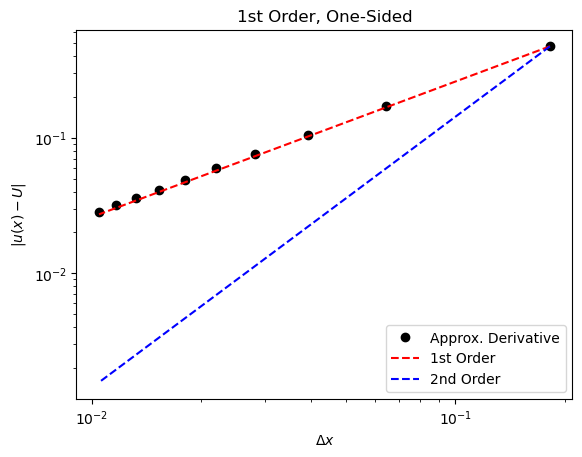

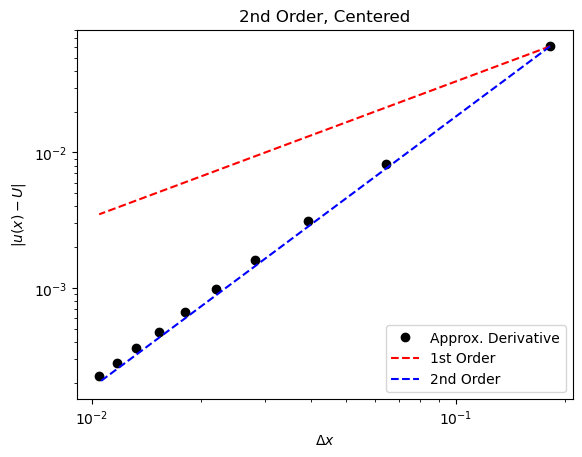

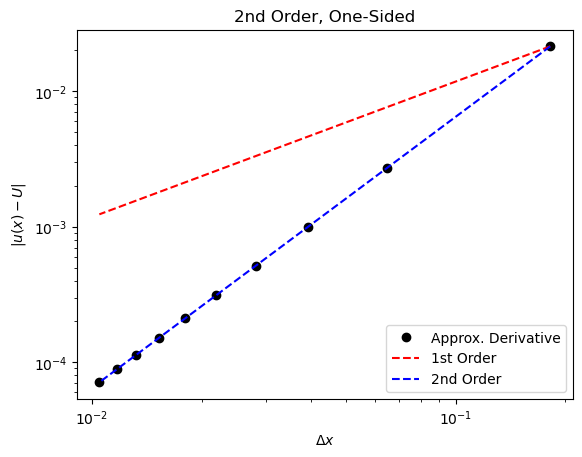

In [6]:
# Problem setup
a = -1.0
b = 1.0
alpha = 3.0
sigma = -5.0
f = lambda x: numpy.exp(x)
u_true = lambda x: -(5.0 + numpy.exp(1.0)) * x - (2.0 + numpy.exp(1.0) + numpy.exp(-1.0)) + numpy.exp(x)

# Compute the error as a function of delta_x
m_range = numpy.arange(10, 200, 20)
delta_x = numpy.empty(m_range.shape)
error = numpy.empty((m_range.shape[0], 3))
for (i, m) in enumerate(m_range):
    
    x = numpy.linspace(a, b, m + 2)
    delta_x[i] = (b - a) / (m + 1)

    # Compute solution
    _, U = solve_mixed_1st_order_one_sided(m)
    error[i, 0] = numpy.linalg.norm(U - u_true(x), ord=numpy.inf)
    _, U = solve_mixed_2nd_order_one_sided(m)
    error[i, 1] = numpy.linalg.norm(U - u_true(x), ord=numpy.inf)
    _, U = solve_mixed_2nd_order_centered(m)
    error[i, 2] = numpy.linalg.norm(U - u_true(x), ord=numpy.inf)
    
titles = ["1st Order, One-Sided", "2nd Order, Centered", "2nd Order, One-Sided"]
order_C = lambda delta_x, error, order: numpy.exp(numpy.log(error) - order * numpy.log(delta_x))
for i in range(3):
    fig = plt.figure()
    axes = fig.add_subplot(1, 1, 1)

    axes.loglog(delta_x, error[:, i], 'ko', label="Approx. Derivative")

    axes.loglog(delta_x, order_C(delta_x[0], error[0,i], 1.0) * delta_x**1.0, 'r--', label="1st Order")
    axes.loglog(delta_x, order_C(delta_x[0], error[0,i], 2.0) * delta_x**2.0, 'b--', label="2nd Order")
    axes.legend(loc=4)
    axes.set_title(titles[i])
    axes.set_xlabel("$\Delta x$")
    axes.set_ylabel("$|u(x) - U|$")


plt.show()

U = solve_mixed_1st_order_one_sided(10)
U = solve_mixed_2nd_order_one_sided(10)
U = solve_mixed_2nd_order_centered(10)

## Eksistensi dan Keunikan

Satu pertanyaan yang sebaiknya diajukan sebelum memulai **solusi numerik** dari suatu persamaan adalah apakah persamaan asli itu **well-posed**.
**Well-posedness** didefinisikan sebagai suatu masalah yang:
1. memiliki **solusi unik**, dan
2. **bergantung secara kontinu** pada data input (misalnya kondisi awal dan kondisi batas).

Pertimbangkan **BVP** yang telah kita pelajari, tetapi kali ini **dengan kondisi batas Neumann murni**:

$$
    u''(x) = f(x) \quad \Omega = [0, 1] \\
    u'(0) = \sigma_0 \quad u'(1) = \sigma_1.
$$

Kita dapat dengan mudah **mendiskretisasi** ini menggunakan salah satu metode yang telah kita kembangkan di atas, tetapi kita akan menemui **masalah**.


In [7]:
# Problem setup
a = -1.0
b = 1.0
alpha = 3.0
sigma = -5.0
f = lambda x: numpy.exp(x)

# Descretization
m = 50
x_bc = numpy.linspace(a, b, m + 2)
x = x_bc[1:-1]
delta_x = (b - a) / (m + 1)

# Construct matrix A
A = numpy.zeros((m + 2, m + 2))
diagonal = numpy.ones(m + 2) / delta_x**2
A += numpy.diag(diagonal * -2.0, 0)
A += numpy.diag(diagonal[:-1], 1)
A += numpy.diag(diagonal[:-1], -1)

# Construct RHS
b = f(x_bc)

# Boundary conditions
A[0, 0] = -1.0 / delta_x
A[0, 1] = 1.0 / delta_x
A[-1, -1] = -1.0 / (delta_x)
A[-1, -2] =  1.0 / (delta_x)

b[0] = delta_x / 2.0 * f(x_bc[0]) - alpha
b[-1] = delta_x / 2.0 * f(x_bc[-1]) - sigma

# Solve system
try:
    U = numpy.linalg.solve(A, b)
except numpy.linalg.LinAlgError as e:
    print(e)
    import traceback
    traceback.print_exc()

Singular matrix


Traceback (most recent call last):
  File "C:\Users\THINKPAD T490\AppData\Local\Temp\ipykernel_9072\3331781132.py", line 35, in <module>
    U = numpy.linalg.solve(A, b)
  File "c:\Users\THINKPAD T490\miniconda3\envs\pengprog\Lib\site-packages\numpy\linalg\_linalg.py", line 410, in solve
    r = gufunc(a, b, signature=signature)
  File "c:\Users\THINKPAD T490\miniconda3\envs\pengprog\Lib\site-packages\numpy\linalg\_linalg.py", line 104, in _raise_linalgerror_singular
    raise LinAlgError("Singular matrix")
numpy.linalg.LinAlgError: Singular matrix


Kita dapat melihat **mengapa $A$ bersifat singular**: vektor konstan $e = [1, 1, 1, 1, 1, \ldots, 1]^T$
sebenarnya berada di **null-space** dari $A$.
Metode numerik kita sebenarnya menunjukkan bahwa masalah ini **ill-posed**!
Memang, karena kondisi batas hanya pada turunan, terdapat tak hingga banyak solusi untuk BVP ini (hal yang sama juga bisa terjadi jika tidak ada solusi sama sekali).

Cara lain untuk memahami mengapa hal ini terjadi adalah dengan **meninjau kembali masalah ini sebagai masalah keadaan tunak** yang berasal dari persamaan panas. Pertimbangkan persamaan panas dengan $\sigma_0 = \sigma_1 = 0$ dan $f(x) = 0$ Konfigurasi ini akan **mempertahankan panas dalam batang**, karena tidak ada panas yang bisa keluar melalui ujung-ujung batang.
Sebenarnya, solusi dari **masalah keadaan tunak** hanyalah **mendistribusikan panas secara merata** di seluruh batang berdasarkan kondisi awal.
Dengan demikian, kita akan memiliki solusi:

$$
u(x) = \int_0^1 u^0(x) , dx = C,
$$

di mana $C$ adalah konstanta.

Masalah muncul karena masalah keadaan tunak tidak mengetahui informasi ini secara mandiri.

Solusinya serupa jika kita memiliki konfigurasi yang sama, tetapi $f(x) \neq 0$.
Sekarang kita **menambahkan atau mengurangi panas** dalam batang. Dalam kasus ini, mungkin **tidak ada keadaan tunak sama sekali**!
Sebenarnya, kita dapat menunjukkan bahwa jika penambahan dan pengurangan panas saling meniadakan secara tepat, maka kita **mungkin memiliki solusi** jika:

$$
\int_0^1 f(x) , dx = 0,
$$

yang kembali **menghasilkan jumlah solusi tak hingga**.


## Diskretisasi Linear Orde Kedua Umum

Sekarang mari kita deskripsikan metode untuk menyelesaikan persamaan:

$$
    a(x) u''(x) + b(x) u'(x) + c(x) u(x) = f(x) \quad \Omega = [a, b] \\
    u(a) = \alpha \quad u(b) = \beta.
$$

Cobalah mendiskretisasi ini menggunakan finite differences orde kedua dan tuliskan sistemnya untuk:

$$
    a(x) u''(x) + b(x) u'(x) + c(x) u(x) = f(x) \quad \Omega = [a, b] \\
    u(a) = \alpha \quad u(b) = \beta.
$$

Aproksimasi finite difference orde kedua secara umum untuk persamaan di atas dapat ditulis sebagai:

$$
a_i \frac{U_{i+1} - 2 U_i + U_{i-1}}{\Delta x^2} + b_i \frac{U_{i+1} - U_{i-1}}{2 \Delta x} + c_i U_i = f_i,
$$

yang menghasilkan entri matriks:

* Pada **diagonal utama**:
  $$
  A_{i,i} = -\frac{2 a_i}{\Delta x^2} + c_i,
  $$

* Pada **sub-diagonal**:
  $$
  A_{i,i\pm1} = \frac{a_i}{\Delta x^2} \pm \frac{b_i}{2 \Delta x}.
  $$

Kita dapat menangani **kondisi batas** dengan menggunakan pendekatan ghost-points atau dengan menggabungkannya ke dalam evaluasi sisi kanan.


### Contoh:

Pertimbangkan masalah konduksi panas keadaan tunak dengan $\kappa(x)$ yang bervariasi sehingga:
$$
    (\kappa(x) u'(x))' = f(x), \quad \Omega = [0, 1] \\
    u(0) = \alpha \quad u(1) = \beta
$$
Berdasarkan **aturan rantai (chain rule)**, kita tahu bahwa:

$$
\kappa(x) u''(x) + \kappa'(x) u'(x) = f(x).
$$

Ternyata, dalam kasus ini, pendekatan ini tidak selalu menjadi cara terbaik untuk menyelesaikan masalah. Dalam banyak kasus, lebih baik mendiskretisasi bentuk fisika aslinya daripada menggunakan formulasi yang mungkin setara.
Untuk mendemonstrasikan hal ini, mari kita coba membangun sistem untuk menyelesaikan persamaan aslinya:

$$
(\kappa(x) u'(x))' = f(x).
$$

Pertama, kita akan mendekati ekspresi

$$
\kappa(x) u'(x)
$$

tetapi pada titik-titik yang berada di tengah-tengah antara titik $x_i$, yaitu $x_{i + 1/2}$.

Kita juga akan menganggap aproksimasi ini efektif sepanjang $\Delta x / 2$ dan memperoleh:

$$
\kappa(x_{i+1/2}) u'(x_{i+1/2}) = \kappa_{i+1/2} \frac{U_{i+1} - U_i}{\Delta x}.
$$

Sekarang, dengan mengambil aproksimasi ini dan menghitung selisihnya menggunakan perbedaan yang sama di sekitar $x_{i-1/2}$, kita memperoleh:

$$\begin{aligned}
    (\kappa(x_i) u'(x_i))' &= \frac{1}{\Delta x} \left [ \kappa_{i+1/2} \frac{U_{i+1} - U_i}{\Delta x} - \kappa_{i-1/2} \frac{U_{i} - U_{i-1}}{\Delta x} \right ] \\
    &= \frac{\kappa_{i+1/2}U_{i+1} - \kappa_{i+1/2} U_i -\kappa_{i-1/2} U_{i} + \kappa_{i-1/2} U_{i-1}}{\Delta x^2} \\ 
    &= \frac{\kappa_{i+1/2}U_{i+1} - (\kappa_{i+1/2} - \kappa_{i-1/2}) U_i + \kappa_{i-1/2} U_{i-1}}{\Delta x^2}
\end{aligned}$$

Perlu dicatat bahwa formulasi ini sebenarnya setara dengan $\mathcal{O}(\Delta x^2)$.

Entri matriksnya adalah:
$$\begin{aligned}
    A_{i,i} = -\frac{\kappa_{i+1/2} - \kappa_{i-1/2}}{\Delta x^2} \\
    A_{i,i \pm 1} = \frac{\kappa_{i\pm 1/2}}{\Delta x^2}.
\end{aligned}$$

Perlu diperhatikan bahwa diskretisasi terakhir ini bersifat simetris. Hal ini akan memiliki konsekuensi terhadap seberapa baik atau cepat kita dapat menyelesaikan sistem persamaan linier yang dihasilkan.


## Persamaan Non-Linear

Masalah model kita, persamaan Poisson, adalah BVP linear.
Bagaimana jika kita menghadapi **masalah non-linear**?
Sebagai masalah model baru, mari kita pertimbangkan masalah pendulum non-linear. Sistem fisiknya adalah sebuah massa $m$ yang terhubung dengan batang kaku tanpa massa sepanjang $L$, yang diizinkan berayun di sekitar suatu titik. Sudut $\theta(t)$ diukur terhadap titik setimbang diam dengan massa menggantung ke bawah.

Sistem ini dapat dijelaskan oleh persamaan:

$$
\theta''(t) = \frac{-g}{L} \sin(\theta(t)).
$$

Untuk kemudahan, kita ambil $\frac{g}{L} = 1$.

Melihat deret Taylor dari $\sin$, kita dapat mendekati persamaan ini untuk $\theta$ kecil sebagai:

$$
\sin(\theta) \approx \theta - \frac{\theta^3}{6} + \mathcal{O}(\theta^5),
$$

sehingga:

$$
\theta'' = -\theta.
$$

Kita tahu bahwa persamaan ini memiliki solusi dalam bentuk:

$$
\theta(t) = C_1 \cos t + C_2 \sin t.
$$

Jelas kita memerlukan dua kondisi batas agar sistem ini terdefinisi secara unik. Hal ini agak berbeda karena biasanya kondisi batas diberikan di dua titik dalam domain spasial, sedangkan di sini kita berada pada domain waktu.
Kita bisa menentukan **posisi awal pendulum**: $\theta(0) = \alpha$. Kondisi kedua bisa menentukan posisi pendulum pada suatu waktu di masa depan, misalnya $\theta(T) = \beta$.
Alternatif lain adalah menentukan **kondisi awal tambahan** seperti kecepatan sudut awal: $\theta'(0) = \sigma$.


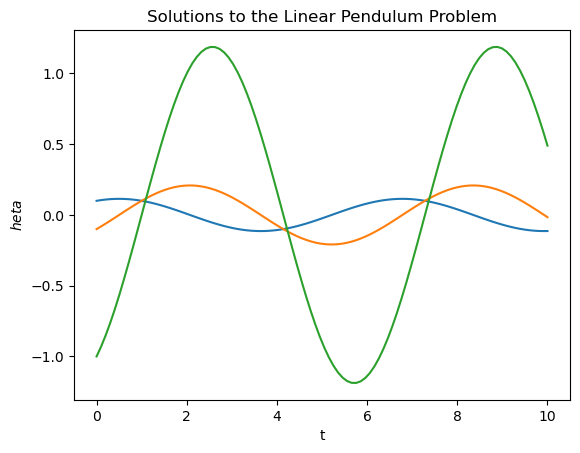

In [8]:
# Simple linear pendulum solutions
def linear_pendulum(t, alpha=0.01, beta=0.01, T=1.0):
    C_1 = alpha
    C_2 = (beta - alpha * numpy.cos(T)) / numpy.sin(T)
    return C_1 * numpy.cos(t) + C_2 * numpy.sin(t)


alpha = [0.1, -0.1, -1.0]
beta = [0.1, 0.1, 0.0]
T = [1.0, 1.0, 1.0]
t = numpy.linspace(0, 10.0, 100)
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
for i in range(len(alpha)):
    axes.plot(t, linear_pendulum(t, alpha[i], beta[i], T[i]))
axes.set_title("Solutions to the Linear Pendulum Problem")
axes.set_xlabel("t")
axes.set_ylabel("$\theta$")

plt.show()

Tapi bagaimana kita menangani masalah yang sepenuhnya non-linear? Pertama, mari kita **diskretisasi** menggunakan pendekatan yang sudah kita pelajari, dengan aproksimasi beda hingga orde kedua, turunan kedua terpusat, sehingga diperoleh:

$$
\frac{1}{\Delta t^2}(\theta_{i+1} - 2 \theta_i + \theta_{i-1}) + \sin (\theta_i) = 0.
$$

Pendekatan yang paling umum untuk menyelesaikan **BVP non-linear** seperti ini (dan banyak PDE non-linear lainnya) adalah menggunakan metode Newton. Ingat bahwa jika kita memiliki fungsi non-linear $G(\theta)$ dan kita ingin mencari $\theta$ sehingga:

$$
G(\theta) = 0,
$$

kita dapat mengembangkan $G(\theta)$ menggunakan deret Taylor:

$$
    G(\theta^{[k+1]}) = G(\theta^{[k]}) + G'(\theta^{[k]}) (\theta^{[k+1]} - \theta^{[k]}) + \mathcal{O}((\theta^{[k+1]} - \theta^{[k]})^2)
$$

Jika kita ingin $G(\theta^{[k+1]}) = 0$, kita bisa menetapkannya pada ekspresi di atas (ini juga dikenal sebagai iterasi titik tetap), dan dengan mengabaikan suku-suku orde lebih tinggi, kita dapat menyelesaikan untuk $\theta^{[k+1]}$ sehingga diperoleh:

$$\begin{aligned}
    0 &= G(\theta^{[k]}) + G'(\theta^{[k]}) (\theta^{[k+1]} - \theta^{[k]} )\\
    G'(\theta^{[k]}) \theta^{[k+1]} &= G'(\theta^{[k]}) \theta^{[k]} - G(\theta^{[k]})
\end{aligned}$$

Pada titik ini kita perlu berhati-hati: jika kita memiliki sistem persamaan, kita tidak bisa sekadar membagi dengan $G'(\theta^{[k]})$ (yang sekarang merupakan matriks) untuk mendapatkan nilai baru $\theta^{[k+1]}$. Sebagai gantinya, kita perlu membalik matriks $G'(\theta^{[k]})$. Cara lain untuk menuliskannya adalah sebagai pembaruan nilai $\theta^{[k+1]}$:

$$
\theta^{[k+1]} = \theta^{[k]} + \delta^{[k]},
$$

dengan

$$
J(\theta^{[k]}) \delta^{[k]} = -G(\theta^{[k]}),
$$

di mana $J(\theta^{[k]})$ adalah jacobian dari $G$ pada iterasi ke-$k$.

Di sini kita telah memperkenalkan notasi untuk matriks Jacobian, yang elemennya didefinisikan sebagai

$$
J_{ij}(\theta) = \frac{\partial}{\partial \theta_j} G_i(\theta).
$$

Jadi, bagaimana kita menghitung matriks Jacobian? Karena kita mengetahui bentuk sistem persamaan dalam kasus ini, kita bisa menuliskan secara umum **elemen-elemen dari $J$**.

Dari persamaan diskret:

$$
\frac{1}{\Delta t^2}(\theta_{i+1} - 2 \theta_i + \theta_{i-1}) + \sin (\theta_i) = 0,
$$

$$
    J_{ij}(\theta) = \left \{ \begin{aligned}
        &\frac{1}{\Delta t^2} & & j = i - 1, j = i + 1 \\
        -&\frac{2}{\Delta t^2} + \cos(\theta_i) & & j = i \\
        &0 & & \text{lainnya}
    \end{aligned} \right .
$$

Dengan Jacobian di tangan, kita dapat menyelesaikan BVP dengan melakukan iterasi sampai suatu kriteria berhenti terpenuhi (artinya kita telah konvergen sesuai tingkat kepuasan kita).


### Contoh

Selesaikan masalah pendulum linier dan non-linier dengan $T = 2\pi$, $\alpha = \beta = 0.7$.

* Apakah persamaan linier memiliki solusi yang unik?
* Apakah Anda memperkirakan masalah asli memiliki solusi yang unik (yaitu, apakah masalah non-linier memiliki solusi yang unik)?


 (1) Step size: 0.2512782262010663
 (2) Step size: 0.0006452832859468563
 (3) Step size: 1.0760234584263571e-08
 (4) Step size: 1.0872594095386544e-14


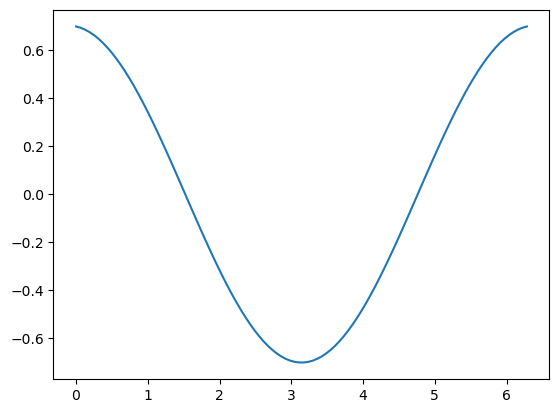

In [9]:
def solve_nonlinear_pendulum(m, alpha, beta, T, max_iterations=100, tolerance=1e-3, verbose=False):
    
    # Discretization
    t_bc = numpy.linspace(0.0, T, m + 2)
    t = t_bc[1:-1]
    delta_t = T / (m + 1)
    diagonal = numpy.ones(t.shape)
    G = numpy.empty(t_bc.shape)
    
    # Initial guess
    theta = 0.7 * numpy.cos(t_bc)
    theta[0] = alpha
    theta[-1] = beta
    
    # Main iteration loop
    success = False
    for num_step in range(1, max_iterations):
        
        # Construct Jacobian matrix
        J = numpy.diag(diagonal * -2.0 / delta_t**2 + numpy.cos(theta[1:-1]), 0)
        J += numpy.diag(diagonal[:-1] / delta_t**2, -1)
        J += numpy.diag(diagonal[:-1] / delta_t**2, 1)
        
        # Construct vector G
        G = (theta[:-2] - 2.0 * theta[1:-1] + theta[2:]) / delta_t**2 + numpy.sin(theta[1:-1])
        
        # Take care of BCs
        G[0] = (alpha - 2.0 * theta[1] + theta[2]) / delta_t**2 + numpy.sin(theta[1])
        G[-1] = (theta[-3] - 2.0 * theta[-2] + beta) / delta_t**2 + numpy.sin(theta[-2])
        
        # Solve
        delta = numpy.linalg.solve(J, -G)
        theta[1:-1] += delta
        
        if verbose:
            print(" (%s) Step size: %s" % (num_step, numpy.linalg.norm(delta)))
        
        if numpy.linalg.norm(delta) < tolerance:
            success = True
            break
            
    if not success:
        print(numpy.linalg.norm(delta))
        raise ValueError("Reached maximum allowed steps before convergence criteria met.")
    
    return t_bc, theta

t, theta = solve_nonlinear_pendulum(100, 0.7, 0.7, 2.0 * numpy.pi, tolerance=1e-9, verbose=True)
plt.plot(t, theta)
plt.show()

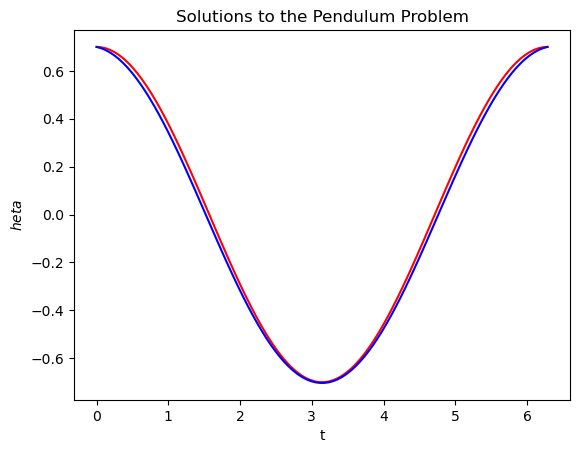

In [10]:
# Linear Problem
alpha = 0.7
beta = 0.7
T = 2.0 * numpy.pi
t = numpy.linspace(0, T, 100)
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(t, linear_pendulum(t, alpha, beta, T), 'r-', label="Linear")

# Non-linear problem
t, theta = solve_nonlinear_pendulum(100, alpha, beta, T)
axes.plot(t, theta, 'b-', label="Non-Linear")

axes.set_title("Solutions to the Pendulum Problem")
axes.set_xlabel("t")
axes.set_ylabel("$\theta$")

plt.show()

### Akurasi

Perlu dicatat bahwa ada dua konsep konvergensi yang berbeda dalam pemecah non-linier kita di atas: satu adalah konvergensi aproksimasi beda hingga yang dikontrol oleh $\Delta x$ dan satu lagi adalah konvergensi iterasi Newton. Kita mengharapkan keduanya bersifat orde dua (metode Newton konvergen secara kuadratik di bawah asumsi yang sesuai). Namun, bagaimana kedua metode ini bergabung untuk memengaruhi kesalahan global?

Pertama, mari kita hitung Local Truncation Error (LTE)
$$\begin{aligned}
    \tau_{i} &= \frac{1}{\Delta t^2} (\theta(t_{i+1}) - 2 \theta(t_i) + \theta(t_{i-1})) + \sin \theta(t_i) \\
    &= \frac{1}{\Delta t^2} \left (\theta(t_i) + \theta'(t_i) \Delta t + \frac{1}{2} \theta''(t_i) \Delta t^2 + \frac{1}{6} \theta'''(t_i) \Delta t^3 + \frac{1}{24} \theta^{(4)}(t_i) \Delta t^4 - 2 \theta(t_i) \right .\\
    &\quad \quad \quad \left . + \theta(t_i) - \theta'(t_i) \Delta t + \frac{1}{2} \theta''(t_i) \Delta t^2 - \frac{1}{6} \theta'''(t_i) \Delta t^3 + \frac{1}{24} \theta^{(4)}(t_i) \Delta t^4 + \mathcal{O}(\Delta t^5) \right) + \sin \theta(t_i) \\
    &= \frac{1}{\Delta t^2} \left (\theta''(t_i) \Delta t^2 + \frac{1}{12} \theta^{(4)}(t_i) \Delta t^4 \mathcal{O}(\Delta t^6) \right) + \sin \theta(t_i) \\
    &= \theta''(t_i)  + \sin \theta(t_i) + \frac{1}{12} \theta^{(4)}(t_i) \Delta t^2 + \mathcal{O}(\Delta t^4).
\end{aligned}$$

Untuk metode Newton, kita dapat mempertimbangkan perbedaan antara mengambil satu langkah dengan solusi sebenarnya dari BVP $\hat{\theta}$ dibandingkan dengan solusi aproksimasi $\theta$. Kita dapat merumuskan LTE yang serupa, di mana
$$
G(\Theta) = 0 \quad \text{dan} \quad G(\hat{\Theta}) = \tau.
$$

Following our discussion from before we can use these two expressions to find
$$
    G(\Theta) - G(\hat{\Theta}) = -\tau
$$
and from here we want to derive an expression of the global error $E = \Theta - \hat{\Theta}$.  

Karena $G(\theta)$ tidak linear, kita akan menulis ekspresi di atas sebagai deret Taylor sehingga diperoleh
$$
G(\Theta) = G(\hat{\Theta}) + J(\hat{\Theta}) E + \mathcal{O}(||E||^2).
$$

Dengan menggunakan ekspresi ini, kita peroleh
$$
J(\hat{\Theta}) E = -\tau + \mathcal{O}(||E||^2).
$$
Jika kita abaikan suku orde tinggi, maka kita mendapatkan ekspresi linear untuk $E$ yang dapat kita selesaikan.

Hal ini memotivasi definisi lain tentang stabilitas yang melibatkan Jacobian dari $G$. Metode beda hingga non-linear $G(\Theta) = 0$ dikatakan *stabil* dalam suatu norma $||\cdot||$ jika matriks $(J_{\Delta t})^{-1}$ terbatas secara seragam dalam norma tersebut saat $\Delta t \rightarrow 0$. Dengan kata lain, ada konstanta $C$ dan $\Delta t^0$ sehingga
$$
||(J_{\Delta t})^{-1}|| \leq C \quad \forall \Delta t < \Delta t^0.
$$

Dengan pemahaman tentang stabilitas ini dan konsistensi $(||\tau|| \rightarrow 0$ saat $\Delta t \rightarrow 0)$, maka metode tersebut konvergen:
$$
||E_{\Delta t}|| \rightarrow 0 \quad \text{seiring} \quad \Delta t \rightarrow 0.
$$

Perlu dicatat bahwa kita tidak dijamin bahwa metode Newton akan konvergen jika tebakan awal buruk, meskipun kita telah menunjukkan konvergensi secara teoretis. Metode Newton dapat dibuktikan akan konvergen jika tebakan awal cukup baik. Juga perlu dicatat bahwa meskipun metode Newton memiliki kesalahan yang kecil, kesalahan akibat pembulatan tidak selalu mengikuti perilaku yang sama.
